Team 16
Traffic Flow Prediction

In [1]:
import numpy as np 
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/kaggle/input/traffic-prediction-dataset/Traffic.csv")

In [3]:
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [4]:
df.tail()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
2971,10:45:00 PM,9,Thursday,16,3,1,36,56,normal
2972,11:00:00 PM,9,Thursday,11,0,1,30,42,normal
2973,11:15:00 PM,9,Thursday,15,4,1,25,45,normal
2974,11:30:00 PM,9,Thursday,16,5,0,27,48,normal
2975,11:45:00 PM,9,Thursday,14,3,1,15,33,normal


In [5]:
df.shape

(2976, 9)

In [6]:
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


In [7]:
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [8]:
df = df.drop('Time', axis=1)
df = df.drop('Day of the week', axis=1)

In [9]:
missing_per=df.isnull().sum()/len(df)*100
print("missing values percentage per column:\n")
print(missing_per)

missing values percentage per column:

Date                 0.0
CarCount             0.0
BikeCount            0.0
BusCount             0.0
TruckCount           0.0
Total                0.0
Traffic Situation    0.0
dtype: float64


In [10]:
threshold=40
columns_to_drop=missing_per[missing_per>threshold].index
df_cleaned=df.drop(columns=columns_to_drop)
print("\ncolumns dropped:",list(columns_to_drop))
print("\ndataset after dropping columns:\n",df_cleaned.info())


columns dropped: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               2976 non-null   int64 
 1   CarCount           2976 non-null   int64 
 2   BikeCount          2976 non-null   int64 
 3   BusCount           2976 non-null   int64 
 4   TruckCount         2976 non-null   int64 
 5   Total              2976 non-null   int64 
 6   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(1)
memory usage: 162.9+ KB

dataset after dropping columns:
 None


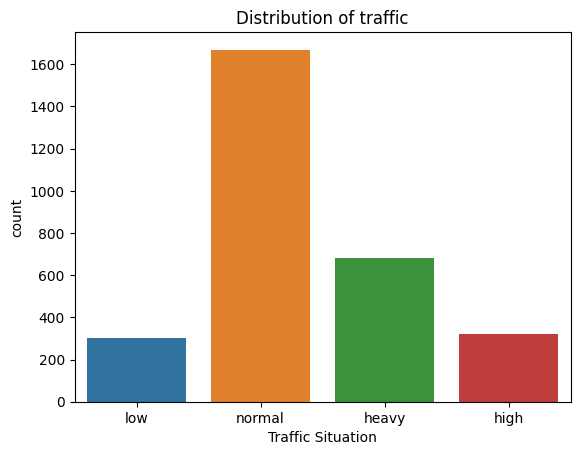

In [11]:
sns.countplot(x='Traffic Situation',data=df)
plt.title("Distribution of traffic")
plt.xlabel("Traffic Situation")
plt.show()

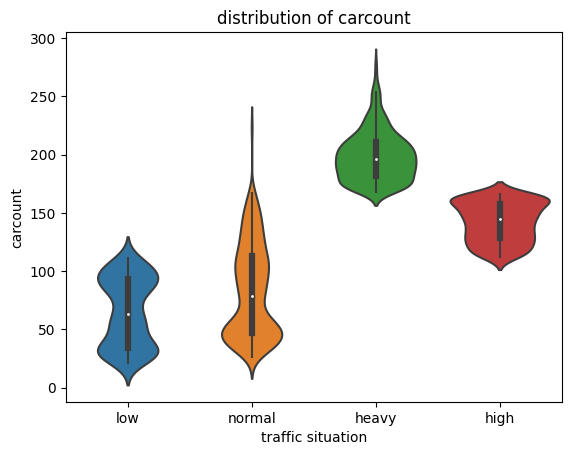

In [12]:
sns.violinplot(x="Traffic Situation",y="Total",data=df)
plt.title("distribution of carcount")
plt.xlabel("traffic situation")
plt.ylabel("carcount")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


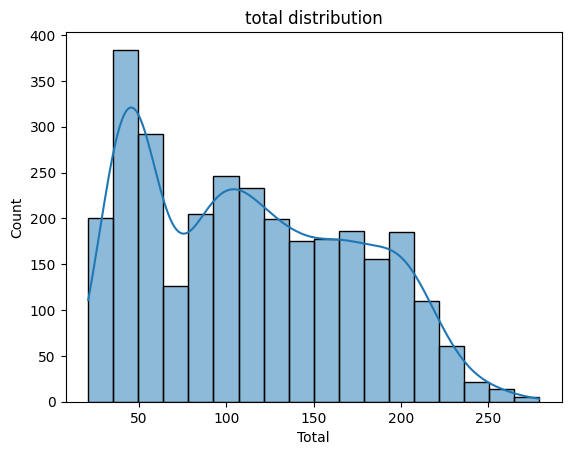

In [13]:
sns.histplot(df["Total"],kde=True)
plt.title("total distribution")
plt.show()

In [14]:
x = df.drop(['Traffic Situation'], axis = 1)
y = df['Traffic Situation']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3,random_state = 42, stratify = y)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (2083, 6)
Shape of X_test: (893, 6)
Shape of y_train: (2083,)
Shape of y_test: (893,)


In [16]:
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame({'Traffic Situation': ['low', 'normal', 'heavy','high']})

# Initialize separate LabelEncoders
le_traffic = LabelEncoder()

df['numerical'] = le_traffic.fit_transform(df['Traffic Situation'])

print(df)

  Traffic Situation  numerical
0               low          2
1            normal          3
2             heavy          0
3              high          1


In [17]:
from sklearn.svm import SVC
model=SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [18]:
y_pred=model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc=accuracy_score(y_test,y_pred)
print("Accuracy:",acc)

Accuracy: 0.8992161254199328


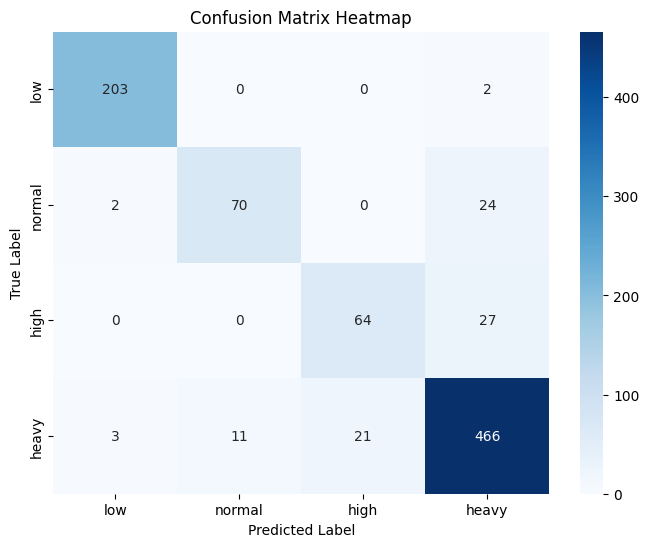

In [20]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
labels = ['low', 'normal', 'high', 'heavy']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [21]:
from sklearn.metrics import classification_report
print("Classification report:\n",classification_report(y_test,y_pred))

Classification report:
               precision    recall  f1-score   support

       heavy       0.98      0.99      0.98       205
        high       0.86      0.73      0.79        96
         low       0.75      0.70      0.73        91
      normal       0.90      0.93      0.91       501

    accuracy                           0.90       893
   macro avg       0.87      0.84      0.85       893
weighted avg       0.90      0.90      0.90       893



In [22]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.n_estimators
rf.fit(X_train,y_train)


RandomForestClassifier()

In [23]:
rf_y_pred=rf.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc=accuracy_score(y_test,rf_y_pred)
print("Accuracy:",acc)

Accuracy: 0.9977603583426652


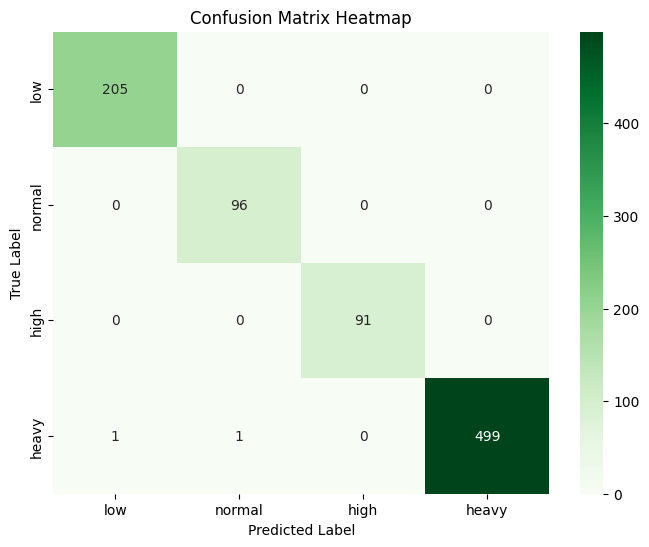

In [25]:
cm=confusion_matrix(y_test,rf_y_pred)
plt.figure(figsize=(8,6))
labels = ['low', 'normal', 'high', 'heavy']
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [26]:
from sklearn.metrics import classification_report
print("Classification report:\n",classification_report(y_test,rf_y_pred))

Classification report:
               precision    recall  f1-score   support

       heavy       1.00      1.00      1.00       205
        high       0.99      1.00      0.99        96
         low       1.00      1.00      1.00        91
      normal       1.00      1.00      1.00       501

    accuracy                           1.00       893
   macro avg       1.00      1.00      1.00       893
weighted avg       1.00      1.00      1.00       893



In [27]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)  
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [28]:
y_lg_pred=model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc=accuracy_score(y_test,y_lg_pred)
print("Accuracy:",acc)

Accuracy: 0.8857782754759238


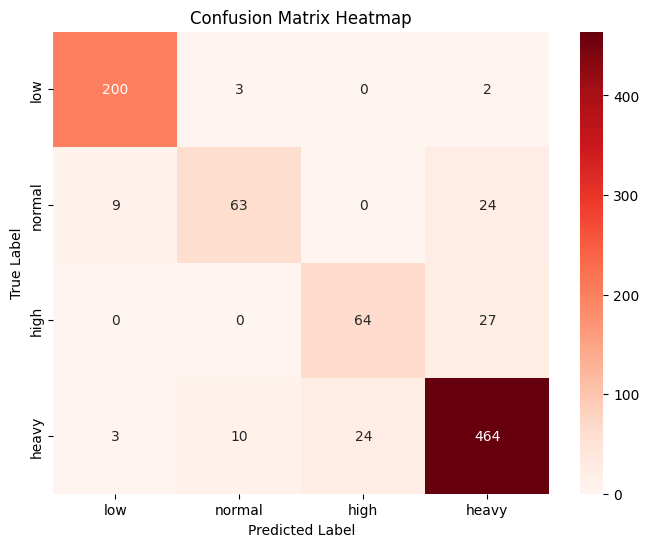

In [30]:
cm=confusion_matrix(y_test,y_lg_pred)
plt.figure(figsize=(8,6))
labels = ['low', 'normal', 'high', 'heavy']
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [31]:
from sklearn.metrics import classification_report
print("Classification report:\n",classification_report(y_test,y_lg_pred))

Classification report:
               precision    recall  f1-score   support

       heavy       0.94      0.98      0.96       205
        high       0.83      0.66      0.73        96
         low       0.73      0.70      0.72        91
      normal       0.90      0.93      0.91       501

    accuracy                           0.89       893
   macro avg       0.85      0.82      0.83       893
weighted avg       0.88      0.89      0.88       893



In [32]:
results = {}

# Accuracy scores
results['SVM (RBF)'] = accuracy_score(y_test,y_pred)
results['Random Forest'] = accuracy_score(y_test,rf_y_pred)
results['Logistic Regression'] = accuracy_score(y_test,y_lg_pred)

comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
comparison_df.sort_values(by='Accuracy', ascending=False)

,Accuracy
Random Forest,0.997760
SVM (RBF),0.899216
Logistic Regression,0.885778


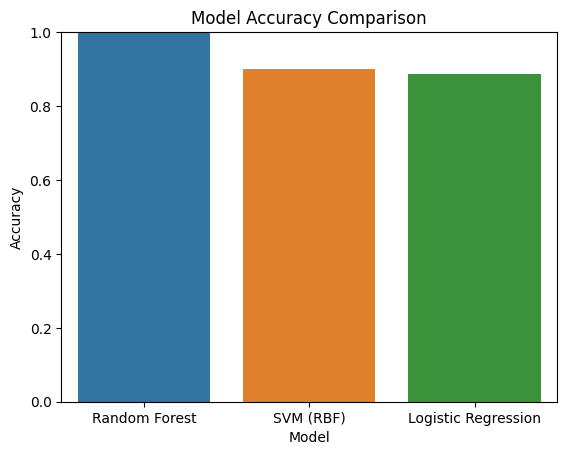

In [33]:
# Plot comparison
comparison_df.sort_values(by='Accuracy', ascending=False, inplace=True)

sns.barplot(x=comparison_df.index, y=comparison_df['Accuracy'])
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

In [34]:
# LDA (max = classes - 1)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

print("Original shape :", X_train.shape)
print("LDA shape      :", X_train_lda.shape)

Original shape : (2083, 6)
LDA shape      : (2083, 3)


Total         0.347374
TruckCount    0.237366
CarCount      0.191201
BusCount      0.164509
BikeCount     0.050127
Date          0.009423
dtype: float64


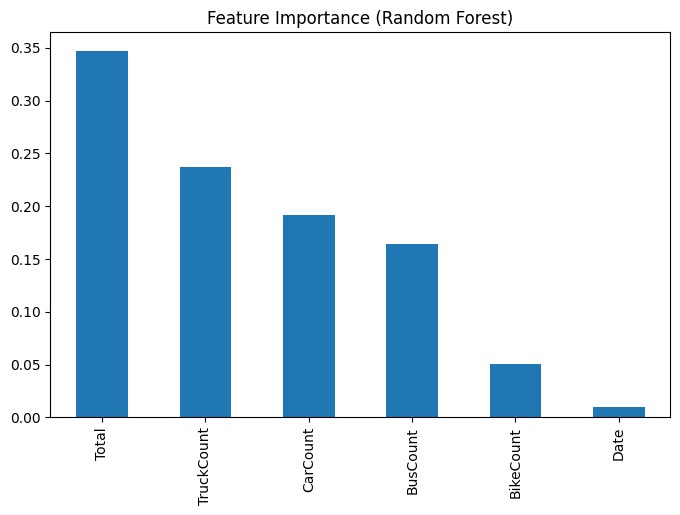

In [35]:
# Feature importance from Random Forest

importances = rf.feature_importances_
feature_names = x.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp)

feat_imp.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.show()